# 03 — WGAN-GP

Wasserstein GAN with Gradient Penalty — improved training stability over DCGAN.

**Key differences from DCGAN:**
- Wasserstein distance instead of BCE loss
- Gradient penalty (λ=10) instead of weight clipping
- Critic trains 5x per generator step
- No sigmoid on discriminator (critic) output

**Reference:** aladdinpersson/Machine-Learning-Collection WGAN-GP

## Setup

In [1]:
!pip install torchxrayvision -q
import os
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from scipy import linalg

import torchxrayvision as xrv

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.0/29.0 MB 67.6 MB/s eta 0:00:00
Device: cuda


In [2]:
# hyperparameters
IMG_SIZE = 64
CHANNELS = 1
NOISE_DIM = 100
FEATURE_G = 64
FEATURE_C = 64  # critic features
BATCH_SIZE = 32
LR = 1e-4
BETA1 = 0.0
BETA2 = 0.9
N_EPOCHS = 50
CRITIC_ITERATIONS = 5  # train critic 5x per generator step
LAMBDA_GP = 10  # gradient penalty coefficient
N_GENERATE = 100

In [3]:
# paths
# DATA_DIR = Path("../data")  # for local use
DATA_DIR = Path("/kaggle/input/datasets/lakshyarathi/lungpp/data")
REAL_DIR = DATA_DIR / "pneumonia"

OUTPUT_DIR = Path("outputs/03_wgan_gp")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

## Dataset Loading

In [4]:
class XrayDataset(Dataset):
    def __init__(self, folder: Path, transform=None):
        self.paths = sorted([
            p for p in folder.iterdir()
            if p.suffix.lower() in {'.png', '.jpg', '.jpeg'} and not p.name.startswith('.')
        ])
        self.transform = transform
    
    def __len__(self):
        return len(self.paths)
    
    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('L')
        if self.transform:
            img = self.transform(img)
        return img

In [5]:
transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

dataset = XrayDataset(REAL_DIR, transform=transform)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, drop_last=True)

print(f"Dataset size: {len(dataset)}")
print(f"Batches per epoch: {len(dataloader)}")

Dataset size: 3875
Batches per epoch: 121


## Model Architecture

Same architecture as DCGAN, but critic has no sigmoid output.

In [6]:
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

In [7]:
class Generator(nn.Module):
    def __init__(self, noise_dim, channels, feature_g):
        super().__init__()
        self.main = nn.Sequential(
            nn.ConvTranspose2d(noise_dim, feature_g * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(feature_g * 8),
            nn.ReLU(True),
            nn.ConvTranspose2d(feature_g * 8, feature_g * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_g * 4),
            nn.ReLU(True),
            nn.ConvTranspose2d(feature_g * 4, feature_g * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_g * 2),
            nn.ReLU(True),
            nn.ConvTranspose2d(feature_g * 2, feature_g, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_g),
            nn.ReLU(True),
            nn.ConvTranspose2d(feature_g, channels, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, x):
        return self.main(x)

In [8]:
class Critic(nn.Module):
    """WGAN critic — no sigmoid, outputs unbounded score."""
    def __init__(self, channels, feature_c):
        super().__init__()
        self.main = nn.Sequential(
            nn.Conv2d(channels, feature_c, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(feature_c, feature_c * 2, 4, 2, 1, bias=False),
            nn.InstanceNorm2d(feature_c * 2, affine=True),  # InstanceNorm for WGAN-GP
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(feature_c * 2, feature_c * 4, 4, 2, 1, bias=False),
            nn.InstanceNorm2d(feature_c * 4, affine=True),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(feature_c * 4, feature_c * 8, 4, 2, 1, bias=False),
            nn.InstanceNorm2d(feature_c * 8, affine=True),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(feature_c * 8, 1, 4, 1, 0, bias=False)
            # no sigmoid — outputs raw score
        )

    def forward(self, x):
        return self.main(x).view(-1)

In [9]:
netG = Generator(NOISE_DIM, CHANNELS, FEATURE_G).to(device)
netC = Critic(CHANNELS, FEATURE_C).to(device)

netG.apply(weights_init)
netC.apply(weights_init)

print(f"Generator parameters: {sum(p.numel() for p in netG.parameters()):,}")
print(f"Critic parameters: {sum(p.numel() for p in netC.parameters()):,}")

Generator parameters: 3,574,656
Critic parameters: 2,763,520


In [10]:
def gradient_penalty(critic, real, fake, device):
    """Compute gradient penalty for WGAN-GP."""
    batch_size, c, h, w = real.shape
    epsilon = torch.rand(batch_size, 1, 1, 1, device=device)
    epsilon = epsilon.expand_as(real)
    
    # interpolate between real and fake
    interpolated = epsilon * real + (1 - epsilon) * fake
    interpolated.requires_grad_(True)
    
    # critic score on interpolated
    critic_interpolated = critic(interpolated)
    
    # compute gradients
    gradients = torch.autograd.grad(
        outputs=critic_interpolated,
        inputs=interpolated,
        grad_outputs=torch.ones_like(critic_interpolated),
        create_graph=True,
        retain_graph=True
    )[0]
    
    gradients = gradients.view(batch_size, -1)
    gradient_norm = gradients.norm(2, dim=1)
    gp = ((gradient_norm - 1) ** 2).mean()
    return gp

## Training

In [11]:
optimizerC = optim.Adam(netC.parameters(), lr=LR, betas=(BETA1, BETA2))
optimizerG = optim.Adam(netG.parameters(), lr=LR, betas=(BETA1, BETA2))

fixed_noise = torch.randn(16, NOISE_DIM, 1, 1, device=device)

In [12]:
G_losses = []
C_losses = []

print("Starting training...")

for epoch in range(N_EPOCHS):
    epoch_G_loss = 0.0
    epoch_C_loss = 0.0
    n_critic_updates = 0
    n_gen_updates = 0
    
    pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{N_EPOCHS}")
    
    for batch_idx, real_images in enumerate(pbar):
        real_images = real_images.to(device)
        batch_size = real_images.size(0)
        
        # ---------------------
        # Train Critic (5x per generator step)
        # ---------------------
        for _ in range(CRITIC_ITERATIONS):
            netC.zero_grad()
            
            noise = torch.randn(batch_size, NOISE_DIM, 1, 1, device=device)
            fake_images = netG(noise)
            
            # Wasserstein loss: maximize E[C(real)] - E[C(fake)]
            # equivalent to minimizing -E[C(real)] + E[C(fake)]
            critic_real = netC(real_images).mean()
            critic_fake = netC(fake_images.detach()).mean()
            
            gp = gradient_penalty(netC, real_images, fake_images.detach(), device)
            
            lossC = -critic_real + critic_fake + LAMBDA_GP * gp
            lossC.backward()
            optimizerC.step()
            
            epoch_C_loss += lossC.item()
            n_critic_updates += 1
        
        # ---------------------
        # Train Generator
        # ---------------------
        netG.zero_grad()
        
        noise = torch.randn(batch_size, NOISE_DIM, 1, 1, device=device)
        fake_images = netG(noise)
        
        # generator wants to maximize E[C(fake)] = minimize -E[C(fake)]
        lossG = -netC(fake_images).mean()
        lossG.backward()
        optimizerG.step()
        
        epoch_G_loss += lossG.item()
        n_gen_updates += 1
        
        # Wasserstein distance estimate
        w_dist = critic_real.item() - critic_fake.item()
        pbar.set_postfix({'W_dist': f'{w_dist:.4f}', 'G_loss': f'{lossG.item():.4f}'})
    
    avg_G_loss = epoch_G_loss / n_gen_updates
    avg_C_loss = epoch_C_loss / n_critic_updates
    G_losses.append(avg_G_loss)
    C_losses.append(avg_C_loss)
    
    print(f"Epoch {epoch+1}: C_loss={avg_C_loss:.4f}, G_loss={avg_G_loss:.4f}")
    
    if (epoch + 1) % 10 == 0:
        checkpoint_path = CHECKPOINT_DIR / f"checkpoint_epoch_{epoch+1}.pt"
        torch.save({
            'epoch': epoch + 1,
            'netG_state_dict': netG.state_dict(),
            'netC_state_dict': netC.state_dict(),
            'optimizerG_state_dict': optimizerG.state_dict(),
            'optimizerC_state_dict': optimizerC.state_dict(),
            'G_losses': G_losses,
            'C_losses': C_losses,
        }, checkpoint_path)
        print(f"Saved checkpoint: {checkpoint_path}")

print("Training complete!")

Starting training...


Epoch 1/50: 100%|██████████| 121/121 [00:43<00:00,  2.79it/s, W_dist=9.9722, G_loss=15.8434]


Epoch 1: C_loss=0.2154, G_loss=12.7319


Epoch 2/50: 100%|██████████| 121/121 [00:42<00:00,  2.84it/s, W_dist=8.9089, G_loss=10.8588]


Epoch 2: C_loss=-6.1460, G_loss=13.4187


...

Epoch 48: C_loss=-3.6171, G_loss=-3.3653


Epoch 49/50: 100%|██████████| 121/121 [00:44<00:00,  2.71it/s, W_dist=6.9083, G_loss=-3.1221]


Epoch 49: C_loss=-3.6622, G_loss=-3.1466


Epoch 50/50: 100%|██████████| 121/121 [00:44<00:00,  2.71it/s, W_dist=5.1589, G_loss=-1.9267]

Epoch 50: C_loss=-3.6885, G_loss=-2.7213
Saved checkpoint: outputs/03_wgan_gp/checkpoints/checkpoint_epoch_50.pt
Training complete!


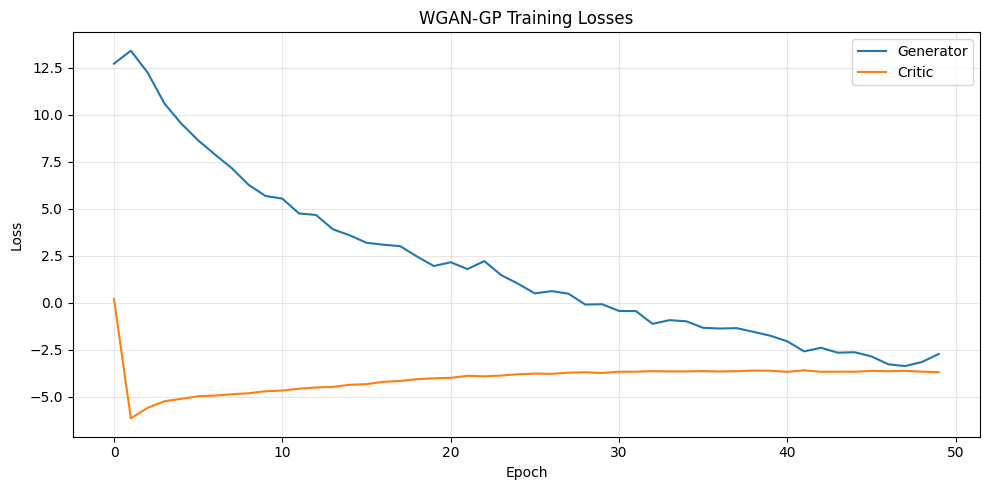

In [13]:
plt.figure(figsize=(10, 5))
plt.plot(G_losses, label='Generator')
plt.plot(C_losses, label='Critic')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('WGAN-GP Training Losses')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "training_curve.png", dpi=150)
plt.show()

## Generate 100 Images

In [14]:
generated_dir = OUTPUT_DIR / "images"
generated_dir.mkdir(parents=True, exist_ok=True)

netG.eval()
generated_paths = []

with torch.no_grad():
    for i in tqdm(range(N_GENERATE), desc="Generating"):
        noise = torch.randn(1, NOISE_DIM, 1, 1, device=device)
        fake = netG(noise)
        
        img = fake.squeeze().cpu().numpy()
        img = ((img + 1) / 2 * 255).astype(np.uint8)
        img = Image.fromarray(img, mode='L')
        
        out_path = generated_dir / f"{i:04d}.png"
        img.save(out_path, 'PNG')
        generated_paths.append(out_path)

print(f"Generated {len(generated_paths)} images")

Generating: 100%|██████████| 100/100 [00:00<00:00, 580.46it/s]

Generated 100 images


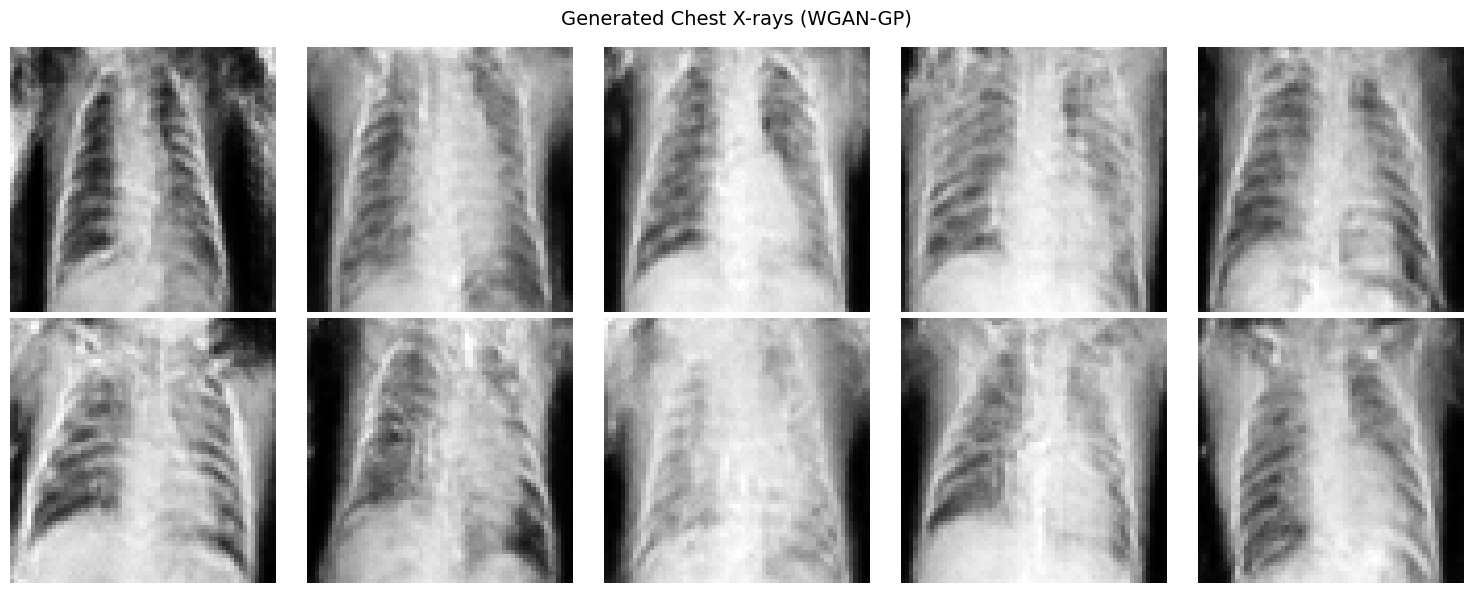

In [15]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Generated Chest X-rays (WGAN-GP)", fontsize=14)

for ax, img_path in zip(axes.flat, generated_paths[:10]):
    img = Image.open(img_path)
    ax.imshow(img, cmap='gray')
    ax.axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "generated_samples.png", dpi=150)
plt.show()

## Evaluate — FID (domain-adapted, DenseNet121 features)

In [16]:
xrv_model = xrv.models.DenseNet(weights="densenet121-res224-all")
xrv_model = xrv_model.to(device)
xrv_model.eval()

feature_extractor = nn.Sequential(*list(xrv_model.features.children()))
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

If this fails you can run `wget https://github.com/mlmed/torchxrayvision/releases/download/v1/nih-pc-chex-mimic_ch-google-openi-kaggle-densenet121-d121-tw-lr001-rot45-tr15-sc15-seed0-best.pt -O /root/.torchxrayvision/models_data/nih-pc-chex-mimic_ch-google-openi-kaggle-densenet121-d121-tw-lr001-rot45-tr15-sc15-seed0-best.pt`
[██████████████████████████████████████████████████]


Sequential(
  (0): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): _DenseBlock(
    (denselayer1): _DenseLayer(
      (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu1): ReLU(inplace=True)
      (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu2): ReLU(inplace=True)
      (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    )
    (denselayer2): _DenseLayer(
      (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu1): ReLU(inplace=True)
      (conv1): Conv2d(96, 128, kernel_size=(1, 1), stride=(

In [17]:
def load_and_preprocess_for_xrv(img_path):
    img = Image.open(img_path).convert('L')
    img = img.resize((224, 224), Image.LANCZOS)
    img = np.array(img, dtype=np.float32)
    img = (img / 255.0) * 2048 - 1024
    img = img[np.newaxis, ...]
    return torch.tensor(img, dtype=torch.float32)


def extract_features(image_paths, batch_size=32):
    features = []
    for i in tqdm(range(0, len(image_paths), batch_size), desc="Extracting features"):
        batch_paths = image_paths[i:i+batch_size]
        batch = torch.stack([load_and_preprocess_for_xrv(p) for p in batch_paths])
        batch = batch.to(device)
        with torch.no_grad():
            feat = feature_extractor(batch)
            feat = feat.mean(dim=[2, 3])
            features.append(feat.cpu().numpy())
    return np.concatenate(features, axis=0)


def compute_fid(real_features, fake_features):
    if len(real_features) < 2 or len(fake_features) < 2:
        return None
    mu_real = np.mean(real_features, axis=0)
    mu_fake = np.mean(fake_features, axis=0)
    sigma_real = np.cov(real_features, rowvar=False)
    sigma_fake = np.cov(fake_features, rowvar=False)
    eps = 1e-6
    sigma_real += np.eye(sigma_real.shape[0]) * eps
    sigma_fake += np.eye(sigma_fake.shape[0]) * eps
    diff = mu_real - mu_fake
    try:
        covmean, _ = linalg.sqrtm(sigma_real @ sigma_fake, disp=False)
        if np.iscomplexobj(covmean):
            covmean = covmean.real
        if not np.isfinite(covmean).all():
            return None
        fid = float(diff @ diff + np.trace(sigma_real + sigma_fake - 2 * covmean))
        return fid if np.isfinite(fid) else None
    except Exception:
        return None

In [18]:
real_paths = sorted([p for p in REAL_DIR.iterdir() if p.suffix == '.png'])[:N_GENERATE]

print("Extracting features from real images...")
real_features = extract_features(real_paths)

print("Extracting features from generated images...")
fake_features = extract_features(generated_paths)

fid_score = compute_fid(real_features, fake_features)
print(f"\nDomain-adapted FID (DenseNet121): {fid_score:.2f}")

Extracting features from real images...


Extracting features: 100%|██████████| 4/4 [00:00<00:00,  5.98it/s]


Extracting features from generated images...


Extracting features: 100%|██████████| 4/4 [00:00<00:00, 10.21it/s]



Domain-adapted FID (DenseNet121): 11.10


## Evaluate — Label + TSTR (torchxrayvision)

In [19]:
def label_images(image_paths, batch_size=32):
    all_predictions = []
    for i in tqdm(range(0, len(image_paths), batch_size), desc="Labeling"):
        batch_paths = image_paths[i:i+batch_size]
        batch = torch.stack([load_and_preprocess_for_xrv(p) for p in batch_paths])
        batch = batch.to(device)
        with torch.no_grad():
            outputs = xrv_model(batch)
            all_predictions.append(outputs.cpu().numpy())
    return np.concatenate(all_predictions, axis=0)

In [20]:
predictions = label_images(generated_paths)
pathology_names = xrv_model.pathologies

pneumonia_idx = next(
    (i for i, name in enumerate(pathology_names) if 'lung opacity' in name.lower()),
    None
)
print(f"Using pathology index {pneumonia_idx}: {pathology_names[pneumonia_idx]}")

Labeling: 100%|██████████| 4/4 [00:00<00:00,  5.19it/s]

Using pathology index 16: Lung Opacity


In [21]:
pneumonia_scores = predictions[:, pneumonia_idx]
threshold = 0.5
positives = (pneumonia_scores > threshold).sum()
tstr_accuracy = positives / len(pneumonia_scores) * 100

print(f"\nProxy TSTR Results:")
print(f"  Mean pneumonia score: {pneumonia_scores.mean():.3f}")
print(f"  Classified as pneumonia (>{threshold}): {positives}/{len(pneumonia_scores)} ({tstr_accuracy:.1f}%)")


Proxy TSTR Results:
  Mean pneumonia score: 0.941
  Classified as pneumonia (>0.5): 100/100 (100.0%)


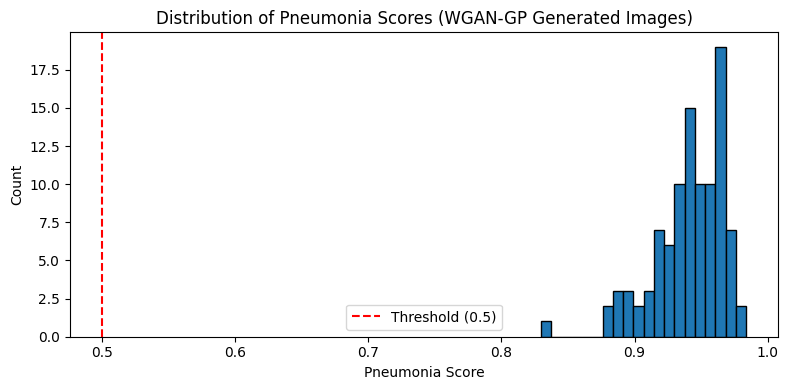

In [22]:
plt.figure(figsize=(8, 4))
plt.hist(pneumonia_scores, bins=20, edgecolor='black')
plt.axvline(threshold, color='red', linestyle='--', label=f'Threshold ({threshold})')
plt.xlabel('Pneumonia Score')
plt.ylabel('Count')
plt.title('Distribution of Pneumonia Scores (WGAN-GP Generated Images)')
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "pneumonia_scores.png", dpi=150)
plt.show()

## Export (images/ + labels.csv + metrics.json)

In [23]:
labels_df = pd.DataFrame({
    'filename': [p.name for p in generated_paths],
    'pneumonia_score': pneumonia_scores,
    'predicted_label': ['pneumonia' if s > threshold else 'normal' for s in pneumonia_scores]
})

for i, name in enumerate(pathology_names):
    labels_df[name] = predictions[:, i]

labels_path = OUTPUT_DIR / "labels.csv"
labels_df.to_csv(labels_path, index=False)
print(f"Saved labels to {labels_path}")

Saved labels to outputs/03_wgan_gp/labels.csv


In [24]:
metrics = {
    'model': 'wgan_gp',
    'n_generated': len(generated_paths),
    'fid_domain_adapted': fid_score,
    'tstr_accuracy': tstr_accuracy,
    'mean_pneumonia_score': float(pneumonia_scores.mean()),
    'epochs': N_EPOCHS,
    'batch_size': BATCH_SIZE,
    'noise_dim': NOISE_DIM,
    'learning_rate': LR,
    'lambda_gp': LAMBDA_GP,
    'critic_iterations': CRITIC_ITERATIONS,
    'final_G_loss': G_losses[-1] if G_losses else None,
    'final_C_loss': C_losses[-1] if C_losses else None,
    'seed': SEED
}

metrics_path = OUTPUT_DIR / "metrics.json"
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=2)

print(f"Saved metrics to {metrics_path}")
print(json.dumps(metrics, indent=2))

Saved metrics to outputs/03_wgan_gp/metrics.json
{
  "model": "wgan_gp",
  "n_generated": 100,
  "fid_domain_adapted": 11.098164794686305,
  "tstr_accuracy": 100.0,
  "mean_pneumonia_score": 0.9410611987113953,
  "epochs": 50,
  "batch_size": 32,
  "noise_dim": 100,
  "learning_rate": 0.0001,
  "lambda_gp": 10,
  "critic_iterations": 5,
  "final_G_loss": -2.7212891172279012,
  "final_C_loss": -3.688484305783737,
  "seed": 42
}


## Results

In [25]:
print("="*50)
print("WGAN-GP RESULTS")
print("="*50)
print(f"Images generated: {len(generated_paths)}")
print(f"Training epochs: {N_EPOCHS}")
print(f"Domain-adapted FID: {fid_score:.2f}")
print(f"Proxy TSTR accuracy: {tstr_accuracy:.1f}%")
print(f"Mean pneumonia score: {pneumonia_scores.mean():.3f}")
print(f"Final G loss: {G_losses[-1]:.4f}")
print(f"Final C loss: {C_losses[-1]:.4f}")
print("="*50)

WGAN-GP RESULTS
Images generated: 100
Training epochs: 50
Domain-adapted FID: 11.10
Proxy TSTR accuracy: 100.0%
Mean pneumonia score: 0.941
Final G loss: -2.7213
Final C loss: -3.6885
